# Phase 5.2 - Brutal Stress Test (Cross-Dataset Blind Evaluation)

This notebook performs a limit-testing, blind cross-dataset evaluation of the RAG-IDS pipeline.

It measures:
- per-flow latency with `time.perf_counter_ns()`
- fusion behavior using exponential weighting $e^{2.0 \times sim}$
- Born-rule normalization and Shannon entropy
- confusion matrix and uncertainty routing behavior

In [5]:
import time
import math
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as ads
import chromadb

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    accuracy_score,
)

NOTEBOOK_DIR = Path.cwd()
MAIN_DIR = NOTEBOOK_DIR.parent
DATA_DIR = MAIN_DIR / 'data'
OCEAN_DIR = DATA_DIR / 'unified' / 'ocean_v51'
ARTIFACTS_DIR = MAIN_DIR / 'artifacts'
PREPROCESSORS_PATH = ARTIFACTS_DIR / 'preprocessors_v51.pkl'
CHROMA_DIR = MAIN_DIR / 'chromadb_store_v51'
COLLECTION_NAME = 'ids_knowledge_base_v51'

assert PREPROCESSORS_PATH.exists(), f'Missing preprocessors: {PREPROCESSORS_PATH}'
assert OCEAN_DIR.exists(), f'Missing unified ocean path: {OCEAN_DIR}'
assert CHROMA_DIR.exists(), f'Missing chroma path: {CHROMA_DIR}'

with open(PREPROCESSORS_PATH, 'rb') as f:
    PP = pickle.load(f)

block1_scalers = PP['block1_scalers']
block6_scalers = PP['block6_scalers']
qt_byte_pkt = PP['qt_byte_pkt']
pt_sport = PP['pt_sport_rarity']
pt_dport = PP['pt_dport_rarity']
sport_rarity = PP['sport_rarity_map']
dport_rarity = PP['dport_rarity_map']
TOTAL_ROWS_OCEAN = PP['total_rows_ocean']

client = chromadb.PersistentClient(path=str(CHROMA_DIR))
collection = client.get_collection(COLLECTION_NAME)

print('Environment ready')
print(f'Collection medoids: {collection.count():,}')

Environment ready
Collection medoids: 75,465


In [6]:
TOTAL_DIMS = 114
RAG_SIM_FLOOR = 70.0

PROTO_TOKENS = ['tcp', 'udp', 'icmp', 'arp', 'ipv6', 'other']
SERVICE_TOKENS = ['dns', 'http', 'ssl', 'ftp', 'ssh', 'smtp', 'dhcp', 'quic', 'ntp', 'rdp', 'pop3', 'other']
STATE_TOKENS = ['PENDING', 'ESTABLISHED', 'REJECTED', 'RESET', 'OTHER']
HTTP_METHOD_TOKENS = ['GET', 'POST', 'PUT', 'DELETE', 'HEAD', 'OPTIONS', 'PATCH', 'OTHER']
SSL_CIPHER_TOKENS = [
    'TLS_ECDHE_RSA_WITH_AES_128_GCM_SHA256',
    'TLS_ECDHE_RSA_WITH_AES_256_GCM_SHA384',
    'TLS_RSA_WITH_AES_128_GCM_SHA256',
    'TLS_RSA_WITH_AES_256_GCM_SHA384',
    'TLS_RSA_WITH_AES_128_CBC_SHA',
    'TLS_RSA_WITH_AES_256_CBC_SHA',
    'TLS_RSA_WITH_RC4_128_SHA',
    'TLS_RSA_WITH_RC4_128_MD5',
    'TLS_RSA_WITH_3DES_EDE_CBC_SHA',
    'TLS_DHE_RSA_WITH_AES_128_CBC_SHA',
    'TLS_ECDHE_ECDSA_WITH_AES_128_GCM_SHA256',
    'other',
]

SCADA_PORTS = frozenset({502, 102, 44818})
IOT_MGMT_PORTS = frozenset({1883, 5683, 8883})
WEB_PORTS = frozenset({80, 443, 8080})
NET_CORE_PORTS = frozenset({53, 67, 68, 123})
REMOTE_PORTS = frozenset({22, 23, 3389})

_PROTO_IDX = {t: i for i, t in enumerate(PROTO_TOKENS)}
_SVC_IDX = {t: i for i, t in enumerate(SERVICE_TOKENS)}
_STATE_IDX = {t: i for i, t in enumerate(STATE_TOKENS)}
_METHOD_IDX = {t: i for i, t in enumerate(HTTP_METHOD_TOKENS)}
_CIPHER_IDX = {t: i for i, t in enumerate(SSL_CIPHER_TOKENS)}
_ABSENT_SVCS = frozenset({'<absent>', '-', 'unknown', '', 'none', '(empty)', 'nan'})
_DNS_QTYPE_MAP = {1: 0, 2: 1, 5: 2, 6: 3, 12: 4, 15: 5, 16: 6, 28: 7, 33: 8, 255: 9}
_WEAK_SSL_VER = frozenset({'sslv2', 'sslv3', 'tlsv1', 'tlsv10', 'tlsv1.0', 'tls1.0'})
_STRONG_SSL_VER = frozenset({'tlsv12', 'tlsv13', 'tlsv1.2', 'tlsv1.3', 'tls1.2', 'tls1.3'})

def _classify_port_vec(port_series):
    p = pd.to_numeric(port_series, errors='coerce').fillna(-1).astype(int)
    result = np.full(len(p), 6, dtype=np.int8)
    for _, func_idx, pset in [(0, 0, SCADA_PORTS), (1, 1, IOT_MGMT_PORTS), (2, 2, WEB_PORTS), (3, 3, NET_CORE_PORTS), (4, 4, REMOTE_PORTS)]:
        result[p.isin(pset).values] = func_idx
    result[(p.values > 49152) & (result == 6)] = 5
    return result

def vectorize_v51(df):
    n = len(df)
    X = np.zeros((n, TOTAL_DIMS), dtype=np.float32)
    idx = df.index

    def _col(name, fill=0.0):
        return df[name].fillna(fill) if name in df.columns else pd.Series(fill, index=idx)

    def _str_col(name, fill=''):
        return (df[name].fillna(fill).astype(str).str.lower().str.strip()
                if name in df.columns else pd.Series(fill, index=idx))

    for col, mode, out_i in [('univ_duration', 'rs', 0), ('univ_bytes_in', 'qt', 1), ('univ_bytes_out', 'qt', 2), ('univ_pkts_in', 'qt', 3), ('univ_pkts_out', 'qt', 4)]:
        vals = np.clip(_col(col, 0.0).values.astype(np.float64), 0.0, None)
        if mode == 'qt' and col in qt_byte_pkt:
            X[:, out_i] = qt_byte_pkt[col].transform(vals.reshape(-1, 1)).ravel().astype(np.float32)
        elif mode == 'rs' and col in block1_scalers:
            X[:, out_i] = block1_scalers[col].transform(np.log1p(vals).reshape(-1, 1)).ravel().astype(np.float32)

    proto = _str_col('raw_proto', 'other')
    X[np.arange(n), 5 + proto.map(lambda p: _PROTO_IDX.get(p, _PROTO_IDX['other'])).values] = 1.0

    has_svc = _col('has_svc', 0).values.astype(np.float32)
    svc = _str_col('raw_service', 'other')
    other_svc = _SVC_IDX['other']
    svc_idx = svc.map(lambda s: _SVC_IDX.get(s, other_svc) if s not in _ABSENT_SVCS else other_svc).values
    svc_ohe = np.zeros((n, 12), dtype=np.float32)
    svc_ohe[np.arange(n), svc_idx] = 1.0
    X[:, 11:23] = svc_ohe * has_svc[:, np.newaxis]

    state = (df['raw_state_v51'].fillna('OTHER').astype(str).str.upper()
             if 'raw_state_v51' in df.columns else pd.Series('OTHER', index=idx))
    X[np.arange(n), 23 + state.map(lambda s: _STATE_IDX.get(s, _STATE_IDX['OTHER'])).values] = 1.0

    X[np.arange(n), 28 + _classify_port_vec(_col('raw_sport', -1))] = 1.0
    X[np.arange(n), 35 + _classify_port_vec(_col('raw_dport', -1))] = 1.0

    default_r = 1.0 / max(TOTAL_ROWS_OCEAN, 1)
    sport_str = _col('raw_sport', -1).values.astype(int).astype(str)
    dport_str = _col('raw_dport', -1).values.astype(int).astype(str)
    sr = np.array([sport_rarity.get(p, default_r) for p in sport_str], dtype=np.float64)
    dr = np.array([dport_rarity.get(p, default_r) for p in dport_str], dtype=np.float64)
    if pt_sport is not None:
        X[:, 42] = pt_sport.transform(sr.reshape(-1, 1)).ravel().astype(np.float32)
    if pt_dport is not None:
        X[:, 43] = pt_dport.transform(dr.reshape(-1, 1)).ravel().astype(np.float32)

    has_dns = _col('has_dns', 0).values.astype(np.float32)
    qtype = _col('dns_qtype', -1).values.astype(int)
    qclass = _col('dns_qclass', -1).values.astype(int)
    rcode = _col('dns_rcode', -1).values.astype(int)
    qt_arr = np.zeros((n, 10), dtype=np.float32)
    for code, qi in _DNS_QTYPE_MAP.items():
        qt_arr[qtype == code, qi] = 1.0
    qt_arr[(qtype > 0) & ~np.isin(qtype, list(_DNS_QTYPE_MAP.keys())), 9] = 1.0
    X[:, 44:54] = qt_arr * has_dns[:, np.newaxis]

    qc_arr = np.zeros((n, 3), dtype=np.float32)
    qc_arr[qclass == 1, 0] = 1.0
    qc_arr[qclass == 3, 1] = 1.0
    qc_arr[(qclass >= 0) & (qclass != 1) & (qclass != 3), 2] = 1.0
    X[:, 54:57] = qc_arr * has_dns[:, np.newaxis]
    X[:, 57] = ((rcode == 0) & (has_dns > 0)).astype(np.float32)
    X[:, 58] = ((rcode > 0) & (has_dns > 0)).astype(np.float32)

    has_http = _col('has_http', 0).values.astype(np.float32)
    http_m = (df['raw_http_method'].fillna('-').astype(str).str.strip().str.upper()
              if 'raw_http_method' in df.columns else pd.Series('-', index=idx))
    m_idx = http_m.map(lambda m: _METHOD_IDX.get(m, _METHOD_IDX['OTHER'])).values
    m_arr = np.zeros((n, 8), dtype=np.float32)
    valid_m = (http_m != '-') & (http_m != '') & (http_m != 'NAN')
    m_arr[valid_m.values, m_idx[valid_m.values]] = 1.0
    X[:, 59:67] = m_arr * has_http[:, np.newaxis]

    http_s = _col('http_status_code', -1).values.astype(int)
    s_arr = np.zeros((n, 6), dtype=np.float32)
    s_arr[(http_s >= 100) & (http_s < 200), 0] = 1.0
    s_arr[(http_s >= 200) & (http_s < 300), 1] = 1.0
    s_arr[(http_s >= 300) & (http_s < 400), 2] = 1.0
    s_arr[(http_s >= 400) & (http_s < 500), 3] = 1.0
    s_arr[(http_s >= 500) & (http_s < 600), 4] = 1.0
    s_arr[http_s < 0, 5] = 1.0
    X[:, 67:73] = s_arr * has_http[:, np.newaxis]

    req_b = np.clip(_col('http_req_body_len', 0).values.astype(np.float64), 0, 1e7)
    resp_b = np.clip(_col('http_resp_body_len', 0).values.astype(np.float64), 0, 1e7)
    X[:, 73] = (np.log1p(req_b) / np.log1p(1e7)).astype(np.float32) * has_http
    X[:, 74] = (np.log1p(resp_b) / np.log1p(1e7)).astype(np.float32) * has_http
    X[:, 75] = valid_m.values.astype(np.float32) * has_http
    X[:, 76] = (http_s >= 100).astype(np.float32) * has_http
    X[:, 77] = (req_b > 0).astype(np.float32) * has_http
    X[:, 78] = (resp_b > 0).astype(np.float32) * has_http

    has_ssl = _col('has_ssl', 0).values.astype(np.float32)
    ssl_c = (df['raw_ssl_cipher'].fillna('').astype(str).str.strip()
             if 'raw_ssl_cipher' in df.columns else pd.Series('', index=idx))
    c_arr = np.zeros((n, 12), dtype=np.float32)
    c_arr[np.arange(n), ssl_c.map(lambda c: _CIPHER_IDX.get(c, _CIPHER_IDX['other'])).values] = 1.0
    X[:, 80:92] = c_arr * has_ssl[:, np.newaxis]

    ssl_v = (df['raw_ssl_version'].fillna('').astype(str).str.strip().str.lower().str.replace(' ', '').str.replace('.', '')
             if 'raw_ssl_version' in df.columns else pd.Series('', index=idx))
    X[:, 92] = ssl_v.isin(_WEAK_SSL_VER).values.astype(np.float32) * has_ssl
    X[:, 93] = ssl_v.isin(_STRONG_SSL_VER).values.astype(np.float32) * has_ssl
    X[:, 94] = _col('ssl_established', 0).values.astype(np.float32) * has_ssl

    has_unsw = _col('has_unsw', 0).values.astype(np.float32)
    block6 = ['mom_mean', 'mom_stddev', 'mom_sum', 'mom_min', 'mom_max', 'mom_rate',
              'mom_srate', 'mom_drate', 'mom_TnBPSrcIP', 'mom_TnBPDstIP',
              'mom_TnP_PSrcIP', 'mom_TnP_PDstIP', 'mom_TnP_PerProto', 'mom_TnP_Per_Dport']
    for i, col in enumerate(block6):
        if col in block6_scalers:
            info = block6_scalers[col]
            rs = info['scaler']
            shift = info['shift']
            vals = _col(col, -1.0).values.astype(np.float64)
            valid = vals != -1.0
            out = np.zeros(n, dtype=np.float32)
            if valid.any():
                out[valid] = rs.transform(np.log1p(vals[valid] + shift).reshape(-1, 1)).ravel().astype(np.float32)
            X[:, 95 + i] = out * has_unsw

    X[:, 109] = has_svc
    X[:, 110] = has_dns
    X[:, 111] = has_http
    X[:, 112] = has_ssl
    X[:, 113] = has_unsw

    np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    return X

def l2_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0.0, 1.0, norms)
    return (X / norms).astype(np.float32)

In [12]:
def load_cross_dataset_flows(
    target_source='iot23',
    n_rows=100_000,
    normal_ratio=0.5,
    batch_size=200_000,
    random_state=42,
):
    """
    Load a cross-dataset blind slice from unified ocean data.
    target_source should be one of: iot23, toniot, botiot.

    This loader performs stratified collection (NORMAL vs ATTACK) across batches
    to avoid early-slice bias and enforce a mixed-reality evaluation split.
    """
    ds = ads.dataset(str(OCEAN_DIR), format='parquet', partitioning='hive')

    needed_cols = [
        'ubt_archetype', 'dataset_source',
        'univ_duration', 'univ_bytes_in', 'univ_bytes_out', 'univ_pkts_in', 'univ_pkts_out',
        'raw_proto', 'raw_service', 'raw_state_v51', 'raw_sport', 'raw_dport',
        'dns_qtype', 'dns_qclass', 'dns_rcode',
        'raw_http_method', 'http_status_code', 'http_req_body_len', 'http_resp_body_len',
        'raw_ssl_cipher', 'raw_ssl_version', 'ssl_established',
        'mom_mean', 'mom_stddev', 'mom_sum', 'mom_min', 'mom_max',
        'mom_rate', 'mom_srate', 'mom_drate',
        'mom_TnBPSrcIP', 'mom_TnBPDstIP', 'mom_TnP_PSrcIP', 'mom_TnP_PDstIP',
        'mom_TnP_PerProto', 'mom_TnP_Per_Dport',
        'has_svc', 'has_dns', 'has_http', 'has_ssl', 'has_unsw',
        'archetype', 'attack_type', 'label', 'class',
    ]

    avail = set(ds.schema.names)
    cols = [c for c in needed_cols if c in avail]

    n_normal = int(round(n_rows * normal_ratio))
    n_attack = n_rows - n_normal

    normal_parts = []
    attack_parts = []
    normal_count = 0
    attack_count = 0

    label_candidates = ['ubt_archetype', 'archetype', 'attack_type', 'label', 'class']
    label_col = None

    for batch_idx, batch in enumerate(ds.to_batches(columns=cols, batch_size=batch_size)):
        df = batch.to_pandas()
        if 'dataset_source' not in df.columns:
            continue

        part = df[df['dataset_source'].astype(str).str.lower() == str(target_source).lower()]
        if len(part) == 0:
            continue

        if label_col is None:
            label_col = next((c for c in label_candidates if c in part.columns), None)
            if label_col is None:
                continue

        # Shuffle per batch to avoid ordering effects.
        part = part.sample(frac=1.0, random_state=random_state + batch_idx).reset_index(drop=True)
        labels = part[label_col].astype(str).str.upper()

        if normal_count < n_normal:
            take_n = n_normal - normal_count
            chunk = part[labels == 'NORMAL'].iloc[:take_n].copy()
            if len(chunk) > 0:
                normal_parts.append(chunk)
                normal_count += len(chunk)

        if attack_count < n_attack:
            take_a = n_attack - attack_count
            chunk = part[labels != 'NORMAL'].iloc[:take_a].copy()
            if len(chunk) > 0:
                attack_parts.append(chunk)
                attack_count += len(chunk)

        if normal_count >= n_normal and attack_count >= n_attack:
            break

    if label_col is None:
        raise ValueError('No ground-truth label column found in filtered dataset rows.')

    if normal_count < n_normal or attack_count < n_attack:
        raise ValueError(
            f'Insufficient class coverage in source={target_source}. '
            f'Requested NORMAL={n_normal}, ATTACK={n_attack}; '
            f'collected NORMAL={normal_count}, ATTACK={attack_count}. '
            'Try reducing n_rows, changing normal_ratio, or using another source.'
        )

    df_all = pd.concat(normal_parts + attack_parts, ignore_index=True)
    df_all = df_all.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    y_true_bin = (df_all[label_col].astype(str).str.upper() != 'NORMAL').astype(int).values

    normal_final = int((y_true_bin == 0).sum())
    attack_final = int((y_true_bin == 1).sum())

    print(f'Loaded {len(df_all):,} cross-dataset flows from source={target_source}')
    print(f'Ground-truth column: {label_col}')
    print(f'Class split -> NORMAL: {normal_final:,} | ATTACK: {attack_final:,}')
    print(f'Attack ratio: {y_true_bin.mean():.4f}')
    return df_all, y_true_bin

df_blind, y_true = load_cross_dataset_flows(
    target_source='iot23',
    n_rows=100_000,
    normal_ratio=0.5,
)

Loaded 100,000 cross-dataset flows from source=iot23
Ground-truth column: ubt_archetype
Class split -> NORMAL: 50,000 | ATTACK: 50,000
Attack ratio: 0.5000


In [13]:
def query_top3(vec_norm):
    res = collection.query(
        query_embeddings=[vec_norm.tolist()],
        n_results=3,
        include=['metadatas', 'distances']
    )

    neighbors = []
    for md, d in zip(res['metadatas'][0], res['distances'][0]):
        d = max(0.0, float(d))
        sim = (1.0 - d / 2.0)
        neighbors.append({
            'archetype': md.get('ubt_archetype', 'UNKNOWN'),
            'sim': float(np.clip(sim, 0.0, 1.0)),
            'distance': d
        })
    return neighbors

def fuse_top3(neighbors, entropy_gate=0.85):
    if not neighbors:
        return {'attack_prob': 0.0, 'entropy': 1.0, 'entropy_ratio': 1.0, 'verdict': 'MONITOR', 'pred_attack': 0}

    weights = []
    labels = []
    for n in neighbors[:3]:
        w = math.exp(2.0 * n['sim'])
        weights.append(w)
        labels.append(0 if str(n['archetype']).upper() == 'NORMAL' else 1)

    w = np.array(weights, dtype=np.float64)
    p = w / max(np.sum(w), 1e-12)

    p_attack = float(np.sum(p[np.array(labels) == 1]))
    entropy = float(-np.sum(p * np.log2(p + 1e-12)))
    max_entropy = math.log2(max(len(p), 2))
    entropy_ratio = entropy / max_entropy if max_entropy > 0 else 1.0

    top_sim_pct = 100.0 * neighbors[0]['sim']

    if top_sim_pct < 82.0:
        verdict = 'CLEAR'
        pred_attack = 0
    elif p_attack >= 0.95 and top_sim_pct > 90.0:
        verdict = 'CRITICAL'
        pred_attack = 1
    elif p_attack >= 0.85 and top_sim_pct > 85.0:
        verdict = 'WARNING'
        pred_attack = 1
    elif entropy_ratio > entropy_gate:
        verdict = 'MONITOR'
        pred_attack = 0
    else:
        verdict = 'ELEVATED'
        pred_attack = 0

    return {
        'attack_prob': p_attack,
        'entropy': entropy,
        'entropy_ratio': entropy_ratio,
        'top_similarity_pct': top_sim_pct,
        'verdict': verdict,
        'pred_attack': pred_attack
    }

feat_cols = [c for c in df_blind.columns if c not in ['ubt_archetype', 'dataset_source']]
X = vectorize_v51(df_blind[feat_cols])
Xn = l2_normalize(X)

records = []
t0 = time.perf_counter()

for i in range(len(Xn)):
    t_ns_start = time.perf_counter_ns()
    nbs = query_top3(Xn[i])
    fused = fuse_top3(nbs, entropy_gate=0.85)
    t_ns_end = time.perf_counter_ns()

    records.append({
        'idx': i,
        'y_true': int(y_true[i]),
        'y_pred': int(fused['pred_attack']),
        'verdict': fused['verdict'],
        'entropy_ratio': fused['entropy_ratio'],
        'attack_prob': fused['attack_prob'],
        'top_similarity_pct': fused['top_similarity_pct'],
        'latency_us': (t_ns_end - t_ns_start) / 1000.0
    })

elapsed = time.perf_counter() - t0
res_df = pd.DataFrame(records)

print(f'Flood processed: {len(res_df):,} flows')
print(f'Total runtime : {elapsed:.2f} s')
print(f'Throughput    : {len(res_df) / max(elapsed, 1e-9):.0f} pps')

Flood processed: 100,000 flows
Total runtime : 82.82 s
Throughput    : 1207 pps


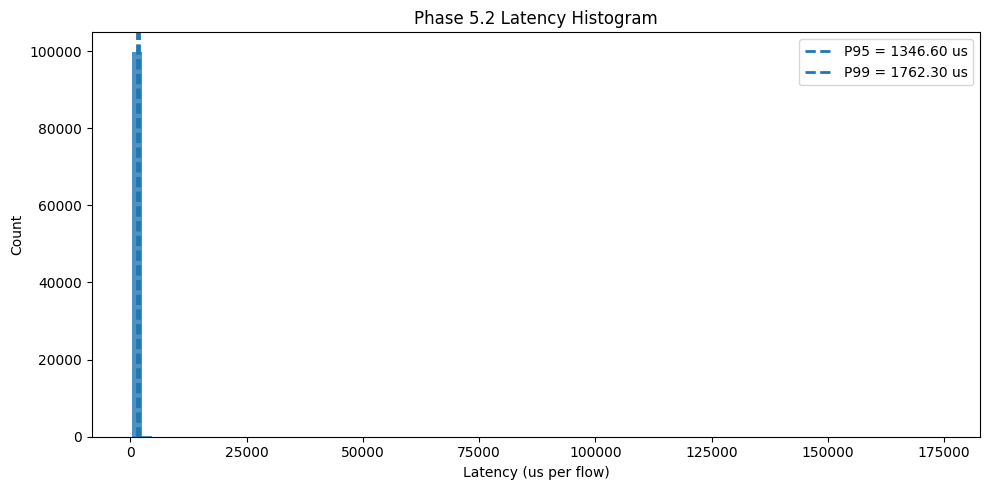

In [14]:
p95 = np.percentile(res_df['latency_us'], 95)
p99 = np.percentile(res_df['latency_us'], 99)

plt.figure(figsize=(10, 5))
plt.hist(res_df['latency_us'], bins=80, alpha=0.8)
plt.axvline(p95, linestyle='--', linewidth=2, label=f'P95 = {p95:.2f} us')
plt.axvline(p99, linestyle='--', linewidth=2, label=f'P99 = {p99:.2f} us')
plt.title('Phase 5.2 Latency Histogram')
plt.xlabel('Latency (us per flow)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

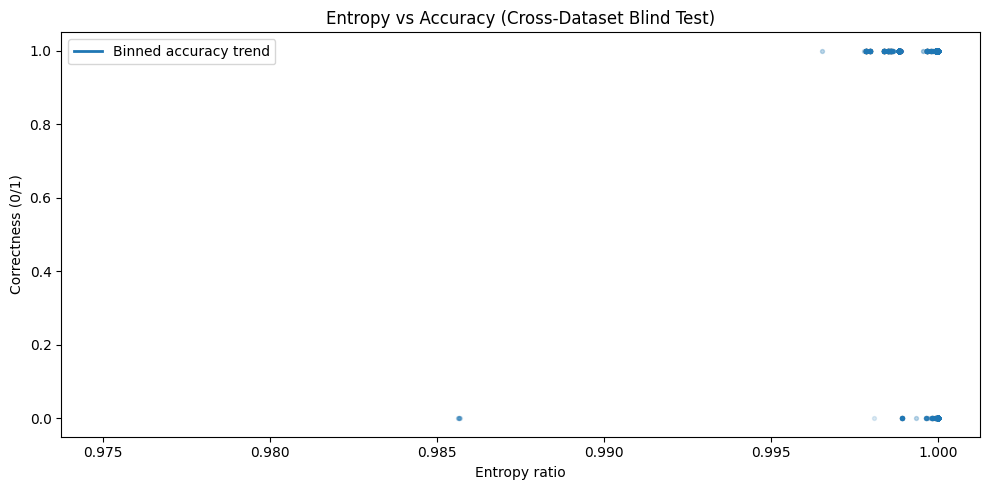

In [15]:
res_df['correct'] = (res_df['y_true'] == res_df['y_pred']).astype(int)

plt.figure(figsize=(10, 5))
plt.scatter(res_df['entropy_ratio'], res_df['correct'], alpha=0.15, s=8)

bins = np.linspace(0, 1, 21)
res_df['entropy_bin'] = pd.cut(res_df['entropy_ratio'], bins, include_lowest=True)
bin_acc = res_df.groupby('entropy_bin', observed=False)['correct'].mean()
bin_mid = np.array([(iv.left + iv.right) / 2.0 for iv in bin_acc.index])
plt.plot(bin_mid, bin_acc.values, linewidth=2, label='Binned accuracy trend')

plt.title('Entropy vs Accuracy (Cross-Dataset Blind Test)')
plt.xlabel('Entropy ratio')
plt.ylabel('Correctness (0/1)')
plt.legend()
plt.tight_layout()
plt.show()

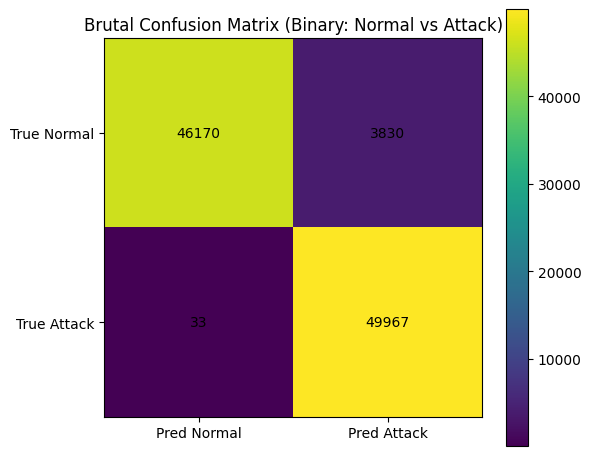

Stress Test Metrics


,metric,value
0,flows,100000.000000
1,mean_latency_us,825.837404
2,p95_latency_us,1346.600000
3,p99_latency_us,1762.302000
4,precision,0.928806
5,accuracy,0.961370
6,monitor_pct,46.166000


In [16]:
cm = confusion_matrix(res_df['y_true'], res_df['y_pred'], labels=[0, 1])

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title('Brutal Confusion Matrix (Binary: Normal vs Attack)')
plt.colorbar()
plt.xticks([0, 1], ['Pred Normal', 'Pred Attack'])
plt.yticks([0, 1], ['True Normal', 'True Attack'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.show()

monitor_pct = 100.0 * (res_df['verdict'] == 'MONITOR').mean()
precision = precision_score(res_df['y_true'], res_df['y_pred'], zero_division=0)
accuracy = accuracy_score(res_df['y_true'], res_df['y_pred'])

summary_df = pd.DataFrame({
    'metric': [
        'flows',
        'mean_latency_us',
        'p95_latency_us',
        'p99_latency_us',
        'precision',
        'accuracy',
        'monitor_pct'
    ],
    'value': [
        len(res_df),
        float(res_df['latency_us'].mean()),
        float(np.percentile(res_df['latency_us'], 95)),
        float(np.percentile(res_df['latency_us'], 99)),
        float(precision),
        float(accuracy),
        float(monitor_pct)
    ]
})

print('Stress Test Metrics')
display(summary_df)